# 🔧 Notebook 02: Preprocesamiento de Datos

**Proyecto:** Sistema de Detección de Phishing con Machine Learning  
**Autor:** [Tu Nombre]  
**Universidad:** [Tu Universidad]  
**Fecha:** 2024-2025

---

## Objetivos

1. ✅ Limpieza de datos (nulos, duplicados, outliers)
2. ✅ Normalización/Estandarización de features
3. ✅ Balanceo de clases (SMOTE)
4. ✅ Split estratificado (70% train, 15% val, 15% test)
5. ✅ Feature engineering y selección
6. ✅ Guardar datos procesados

---

## 1. Importar Librerías

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Módulos propios
from data_loader import DataLoader
from preprocessing import Preprocessor, DataCleaner, FeatureScaler
from feature_engineering import FeatureEngineer

# Configuración
pd.set_option('display.max_columns', None)
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_STATE = 42

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## 2. Cargar Datos

In [2]:
# Cargar dataset
loader = DataLoader(data_dir='../data')
X, y, info = loader.load_all_data(include_external=True)

# IMPORTANTE: Seleccionar solo columnas numéricas
X = X.select_dtypes(include=[np.number])

print(f"Dataset cargado:")
print(f"  - Shape: {X.shape}")
print(f"  - Muestras: {len(X):,}")
print(f"  - Features numericas: {X.shape[1]}")
print(f"\nDistribucion de clases:")
print(y.value_counts())

2025-11-19 17:58:12,438 - data_loader - INFO - UCIDatasetLoader inicializado. Directorio: ../data


2025-11-19 17:58:12,438 - data_loader - INFO - ExternalDataLoader inicializado. Directorio: ../data\external


2025-11-19 17:58:12,438 - data_loader - INFO - DatasetCombiner inicializado


2025-11-19 17:58:12,438 - data_loader - INFO - DataLoader principal inicializado


2025-11-19 17:58:12,438 - data_loader - INFO - === Iniciando carga completa de datos ===


...

2025-11-19 17:58:59,455 - data_loader - INFO - No hay datos externos. Usando solo dataset UCI


2025-11-19 17:58:59,455 - data_loader - INFO - === Carga de datos completada ===


2025-11-19 17:58:59,470 - data_loader - INFO - Total final de samples: 235795


2025-11-19 17:58:59,470 - data_loader - INFO - Balance de clases: {1: 57.189507835195826, 0: 42.810492164804174}


Dataset cargado:
  - Shape: (235795, 50)
  - Muestras: 235,795
  - Features numericas: 50

Distribucion de clases:
1    134850
0    100945
Name: count, dtype: int64


## 3. Limpieza de Datos

### 3.1 Manejo de Valores Nulos

In [3]:
cleaner = DataCleaner()

# Verificar valores nulos
missing_info = cleaner.check_missing_values(X)

if missing_info['total_missing'] > 0:
    print(f"⚠ Valores nulos encontrados: {missing_info['total_missing']}")
    X = cleaner.handle_missing_values(X, strategy='mean')
    print("✓ Valores nulos imputados con la media")
else:
    print("✓ No hay valores nulos")

2025-11-19 17:58:59,509 - preprocessing - INFO - DataCleaner inicializado


2025-11-19 17:58:59,554 - preprocessing - INFO - Valores faltantes totales: 0


✓ No hay valores nulos


### 3.2 Eliminación de Duplicados

In [4]:
initial_count = len(X)
X, y = cleaner.remove_duplicates(X, y)
duplicates_removed = initial_count - len(X)

print(f"Duplicados eliminados: {duplicates_removed}")
print(f"Muestras restantes: {len(X):,}")

2025-11-19 17:58:59,560 - preprocessing - INFO - Eliminando duplicados...


2025-11-19 17:58:59,921 - preprocessing - INFO - Duplicados eliminados: 808


Duplicados eliminados: 808
Muestras restantes: 234,987


### 3.3 Tratamiento de Outliers

In [5]:
# Detectar outliers
outliers = cleaner.detect_outliers_iqr(X, threshold=3.0)
print(f"Outliers detectados: {outliers.sum().sum():,}")

# Decidir si eliminar outliers (opcional - puede afectar el rendimiento)
REMOVE_OUTLIERS = False  # Cambiar a True si se desea eliminar

if REMOVE_OUTLIERS:
    initial_count = len(X)
    X, y = cleaner.remove_outliers(X, y, threshold=3.0, method='iqr')
    removed = initial_count - len(X)
    print(f"✓ Outliers eliminados: {removed:,}")
    print(f"  Muestras restantes: {len(X):,}")
else:
    print("⚠ Outliers detectados pero no eliminados (manteniendo datos originales)")

2025-11-19 17:58:59,948 - preprocessing - INFO - Detectando outliers con IQR (threshold=3.0)...


2025-11-19 17:59:00,176 - preprocessing - INFO - Outliers detectados: 570154


Outliers detectados: 570,154
⚠ Outliers detectados pero no eliminados (manteniendo datos originales)


## 4. Feature Engineering

### 4.1 Análisis de Importancia de Features

In [6]:
engineer = FeatureEngineer(random_state=RANDOM_STATE)

print("Analizando importancia de features...")
print("Esto puede tomar algunos minutos...\n")

# Análisis completo con visualizaciones
results = engineer.analyze_features(
    X, y,
    output_dir='../results/visualizations'
)

print("\n✓ Análisis completado")
print("\nTop 10 features más importantes (Random Forest):")
print(results['importance_rf'].head(10))

2025-11-19 17:59:00,194 - feature_engineering - INFO - FeatureImportanceAnalyzer inicializado


2025-11-19 17:59:00,194 - feature_engineering - INFO - FeatureSelector inicializado


2025-11-19 17:59:00,194 - feature_engineering - INFO - CorrelationAnalyzer inicializado


2025-11-19 17:59:00,194 - feature_engineering - INFO - FeatureEngineer principal inicializado


2025-11-19 17:59:00,194 - feature_engineering - INFO - === Iniciando análisis completo de features ===


...

2025-11-19 18:00:19,007 - feature_engineering - INFO - Gráfica guardada en: ../results/visualizations\feature_importance_mi.png


2025-11-19 18:00:19,007 - feature_engineering - INFO - Generando heatmap de correlación...


2025-11-19 18:00:21,020 - feature_engineering - INFO - Heatmap guardado en: ../results/visualizations\correlation_heatmap.png


2025-11-19 18:00:21,024 - feature_engineering - INFO - === Análisis de features completado ===



✓ Análisis completado

Top 10 features más importantes (Random Forest):
URLSimilarityIndex    0.174760
NoOfExternalRef       0.164230
LineOfCode            0.150320
NoOfSelfRef           0.110095
NoOfImage             0.093312
NoOfJS                0.072390
HasSocialNet          0.031789
NoOfCSS               0.030192
IsHTTPS               0.025503
HasCopyrightInfo      0.024815
dtype: float64


### 4.2 Selección de Features

Seleccionamos las features más relevantes para mejorar el rendimiento.

In [7]:
# Seleccionar top K features
K_FEATURES = 40  # Ajustar según necesidad

X_selected, selected_features = engineer.select_features(
    X, y,
    method='tree_importance',
    k=K_FEATURES
)

print(f"\nFeatures seleccionadas: {len(selected_features)}")
print(f"Shape después de selección: {X_selected.shape}")
print(f"\nFeatures seleccionadas:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

# Usar X_selected para el resto del procesamiento
X = X_selected

2025-11-19 18:00:21,034 - feature_engineering - INFO - Seleccionando 40 features con método: tree_importance


2025-11-19 18:00:21,035 - feature_engineering - INFO - Calculando importancia con Random Forest...


2025-11-19 18:00:29,166 - feature_engineering - INFO - Top 5 features más importantes:
URLSimilarityIndex    0.174760
NoOfExternalRef       0.164230
LineOfCode            0.150320
NoOfSelfRef           0.110095
NoOfImage             0.093312
dtype: float64



Features seleccionadas: 40
Shape después de selección: (234987, 40)

Features seleccionadas:
   1. URLSimilarityIndex
   2. NoOfExternalRef
   3. LineOfCode
   4. NoOfSelfRef
   5. NoOfImage
   6. NoOfJS
   7. HasSocialNet
   8. NoOfCSS
   9. IsHTTPS
  10. HasCopyrightInfo
  11. LargestLineLength
  12. HasDescription
  13. NoOfDegitsInURL
  14. DegitRatioInURL
  15. NoOfOtherSpecialCharsInURL
  16. NoOfLettersInURL
  17. IsResponsive
  18. DomainTitleMatchScore
  19. URLLength
  20. NoOfSubDomain
  21. URLTitleMatchScore
  22. LetterRatioInURL
  23. SpacialCharRatioInURL
  24. HasSubmitButton
  25. NoOfEmptyRef
  26. URLCharProb
  27. CharContinuationRate
  28. HasFavicon
  29. DomainLength
  30. NoOfEqualsInURL
  31. TLDLegitimateProb
  32. NoOfQMarkInURL
  33. NoOfiFrame
  34. HasPasswordField
  35. TLDLength
  36. Robots
  37. Bank
  38. HasTitle
  39. HasHiddenFields
  40. Pay


## 5. Split de Datos (Train/Val/Test)

División estratificada: 70% train, 15% val, 15% test

In [8]:
from preprocessing import DataSplitter

# Crear splitter
splitter = DataSplitter(
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=RANDOM_STATE
)

# Dividir datos
X_train, X_val, X_test, y_train, y_val, y_test = splitter.split(X, y)

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)
print(f"\nTrain set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Phishing: {(y_train == 1).sum():,}")
print(f"  - Legitimate: {(y_train == 0).sum():,}")

print(f"\nValidation set: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Phishing: {(y_val == 1).sum():,}")
print(f"  - Legitimate: {(y_val == 0).sum():,}")

print(f"\nTest set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  - Phishing: {(y_test == 1).sum():,}")
print(f"  - Legitimate: {(y_test == 0).sum():,}")

2025-11-19 18:00:29,206 - preprocessing - INFO - DataSplitter inicializado: train=0.7, val=0.15, test=0.15


2025-11-19 18:00:29,206 - preprocessing - INFO - Dividiendo datos en train/val/test...


2025-11-19 18:00:29,440 - preprocessing - INFO - Train set: 164490 samples


2025-11-19 18:00:29,440 - preprocessing - INFO - Validation set: 35248 samples


2025-11-19 18:00:29,440 - preprocessing - INFO - Test set: 35249 samples


2025-11-19 18:00:29,440 - preprocessing - INFO - Train distribution: {1: 94395, 0: 70095}


2025-11-19 18:00:29,440 - preprocessing - INFO - Val distribution: {1: 20227, 0: 15021}


2025-11-19 18:00:29,440 - preprocessing - INFO - Test distribution: {1: 20228, 0: 15021}


DIVISIÓN DE DATOS

Train set: 164,490 samples (70.0%)
  - Phishing: 94,395
  - Legitimate: 70,095

Validation set: 35,248 samples (15.0%)
  - Phishing: 20,227
  - Legitimate: 15,021

Test set: 35,249 samples (15.0%)
  - Phishing: 20,228
  - Legitimate: 15,021


## 6. Balanceo de Clases

Aplicamos SMOTE solo en el training set para evitar data leakage.

In [9]:
from preprocessing import ClassBalancer

# Verificar si es necesario balancear
balance_ratio = y_train.value_counts().min() / y_train.value_counts().max()
print(f"Balance ratio antes de SMOTE: {balance_ratio:.3f}")

APPLY_BALANCING = balance_ratio < 0.8  # Balancear si ratio < 0.8

if APPLY_BALANCING:
    print("\n⚠ Dataset desbalanceado. Aplicando SMOTE...")
    
    balancer = ClassBalancer(method='smote', random_state=RANDOM_STATE)
    X_train_balanced, y_train_balanced = balancer.balance(X_train, y_train)
    
    print(f"\n✓ Balanceo completado")
    print(f"  Antes: {len(X_train):,} samples")
    print(f"  Después: {len(X_train_balanced):,} samples")
    print(f"\nDistribución después de SMOTE:")
    print(y_train_balanced.value_counts())
    
    # Usar datos balanceados
    X_train = X_train_balanced
    y_train = y_train_balanced
else:
    print("\n✓ Dataset balanceado. No se requiere SMOTE.")

2025-11-19 18:00:29,474 - preprocessing - INFO - ClassBalancer inicializado con método: smote


2025-11-19 18:00:29,475 - preprocessing - INFO - Aplicando balanceo con método: smote


2025-11-19 18:00:29,478 - preprocessing - INFO - Distribución original: {1: 94395, 0: 70095}


Balance ratio antes de SMOTE: 0.743

⚠ Dataset desbalanceado. Aplicando SMOTE...


2025-11-19 18:00:40,902 - preprocessing - INFO - Distribución balanceada: {0: 94395, 1: 94395}


2025-11-19 18:00:40,902 - preprocessing - INFO - Samples después de balanceo: 188790



✓ Balanceo completado
  Antes: 164,490 samples
  Después: 188,790 samples

Distribución después de SMOTE:
__label__
0    94395
1    94395
Name: count, dtype: int64


## 7. Normalización de Features

Importante para modelos como SVM y KNN que son sensibles a la escala.

In [10]:
# Crear scaler (StandardScaler)
scaler = FeatureScaler(scaler_type='standard')

# Ajustar en train y transformar todos los sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Features normalizadas con StandardScaler")
print(f"\nEstadísticas después de normalización (Train set):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))

# Guardar scaler para uso futuro
scaler_path = '../models/scaler.pkl'
scaler.save_scaler(scaler_path)
print(f"\n✓ Scaler guardado en: {scaler_path}")

2025-11-19 18:00:40,921 - preprocessing - INFO - FeatureScaler inicializado con tipo: standard


2025-11-19 18:00:40,921 - preprocessing - INFO - Escalando features con standard...


2025-11-19 18:00:41,082 - preprocessing - INFO - Features escaladas exitosamente


✓ Features normalizadas con StandardScaler

Estadísticas después de normalización (Train set):


2025-11-19 18:00:41,434 - preprocessing - INFO - Scaler guardado en: ../models/scaler.pkl


      URLSimilarityIndex  NoOfExternalRef  LineOfCode  NoOfSelfRef  NoOfImage  \
mean                -0.0              0.0        -0.0         -0.0       -0.0   
std                  1.0              1.0         1.0          1.0        1.0   

      NoOfJS  HasSocialNet  NoOfCSS  IsHTTPS  HasCopyrightInfo  \
mean     0.0           0.0      0.0     -0.0               0.0   
std      1.0           1.0      1.0      1.0               1.0   

      LargestLineLength  HasDescription  NoOfDegitsInURL  DegitRatioInURL  \
mean               -0.0            -0.0              0.0              0.0   
std                 1.0             1.0              1.0              1.0   

      NoOfOtherSpecialCharsInURL  NoOfLettersInURL  IsResponsive  \
mean                         0.0              -0.0           0.0   
std                          1.0               1.0           1.0   

      DomainTitleMatchScore  URLLength  NoOfSubDomain  URLTitleMatchScore  \
mean                    0.0       -0.0     

## 8. Visualización de Datos Preprocesados

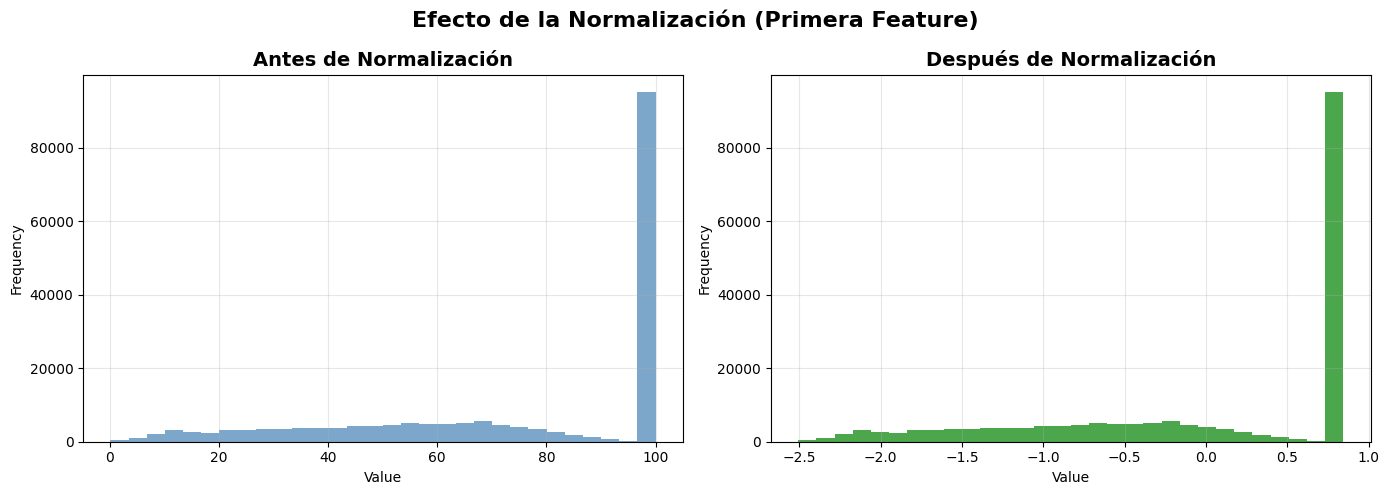

In [11]:
# Comparar distribución antes y después de normalización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes de normalización
ax1 = axes[0]
X_train.iloc[:, 0].hist(bins=30, ax=ax1, color='steelblue', alpha=0.7)
ax1.set_title('Antes de Normalización', fontsize=14, fontweight='bold')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')
ax1.grid(alpha=0.3)

# Después de normalización
ax2 = axes[1]
X_train_scaled.iloc[:, 0].hist(bins=30, ax=ax2, color='green', alpha=0.7)
ax2.set_title('Después de Normalización', fontsize=14, fontweight='bold')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')
ax2.grid(alpha=0.3)

plt.suptitle('Efecto de la Normalización (Primera Feature)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Guardar Datos Preprocesados

In [12]:
import os

# Crear directorio si no existe
os.makedirs('../data/processed', exist_ok=True)

# Guardar datasets
data_to_save = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test
}

for name, data in data_to_save.items():
    filepath = f'../data/processed/{name}.pkl'
    joblib.dump(data, filepath)
    print(f"✓ {name} guardado: {filepath}")

# Guardar lista de features seleccionadas
joblib.dump(selected_features, '../data/processed/selected_features.pkl')
print(f"\n✓ Features seleccionadas guardadas")

print("\n" + "="*60)
print("✅ DATOS PREPROCESADOS GUARDADOS EXITOSAMENTE")
print("="*60)

✓ X_train guardado: ../data/processed/X_train.pkl
✓ X_val guardado: ../data/processed/X_val.pkl
✓ X_test guardado: ../data/processed/X_test.pkl
✓ y_train guardado: ../data/processed/y_train.pkl
✓ y_val guardado: ../data/processed/y_val.pkl
✓ y_test guardado: ../data/processed/y_test.pkl

✓ Features seleccionadas guardadas

✅ DATOS PREPROCESADOS GUARDADOS EXITOSAMENTE


## 10. Resumen del Preprocesamiento

In [13]:
print("="*70)
print("               RESUMEN DEL PREPROCESAMIENTO")
print("="*70)

print(f"\n📊 DATOS PROCESADOS:")
print(f"  - Features originales: {info['final_shape'][1]}")
print(f"  - Features seleccionadas: {len(selected_features)}")
print(f"  - Reducción: {info['final_shape'][1] - len(selected_features)} features")

print(f"\n🔧 TRANSFORMACIONES APLICADAS:")
print(f"  ✓ Valores nulos imputados")
print(f"  ✓ Duplicados eliminados")
if REMOVE_OUTLIERS:
    print(f"  ✓ Outliers eliminados")
if APPLY_BALANCING:
    print(f"  ✓ Balanceo con SMOTE aplicado")
print(f"  ✓ Features normalizadas (StandardScaler)")
print(f"  ✓ Feature selection aplicada")

print(f"\n📁 SPLITS:")
print(f"  - Train: {len(X_train_scaled):,} samples (70%)")
print(f"  - Validation: {len(X_val_scaled):,} samples (15%)")
print(f"  - Test: {len(X_test_scaled):,} samples (15%)")

print(f"\n💾 ARCHIVOS GUARDADOS:")
print(f"  - ../data/processed/X_train.pkl")
print(f"  - ../data/processed/X_val.pkl")
print(f"  - ../data/processed/X_test.pkl")
print(f"  - ../data/processed/y_train.pkl")
print(f"  - ../data/processed/y_val.pkl")
print(f"  - ../data/processed/y_test.pkl")
print(f"  - ../models/scaler.pkl")
print(f"  - ../data/processed/selected_features.pkl")

print("\n" + "="*70)
print("\n✅ PREPROCESAMIENTO COMPLETADO")
print("\n📌 Próximo paso: Notebook 03 - Entrenamiento de Modelos")
print("="*70)

               RESUMEN DEL PREPROCESAMIENTO

📊 DATOS PROCESADOS:
  - Features originales: 54
  - Features seleccionadas: 40
  - Reducción: 14 features

🔧 TRANSFORMACIONES APLICADAS:
  ✓ Valores nulos imputados
  ✓ Duplicados eliminados
  ✓ Balanceo con SMOTE aplicado
  ✓ Features normalizadas (StandardScaler)
  ✓ Feature selection aplicada

📁 SPLITS:
  - Train: 188,790 samples (70%)
  - Validation: 35,248 samples (15%)
  - Test: 35,249 samples (15%)

💾 ARCHIVOS GUARDADOS:
  - ../data/processed/X_train.pkl
  - ../data/processed/X_val.pkl
  - ../data/processed/X_test.pkl
  - ../data/processed/y_train.pkl
  - ../data/processed/y_val.pkl
  - ../data/processed/y_test.pkl
  - ../models/scaler.pkl
  - ../data/processed/selected_features.pkl


✅ PREPROCESAMIENTO COMPLETADO

📌 Próximo paso: Notebook 03 - Entrenamiento de Modelos
